# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra import clustering
from astroExplain.spectra import astronomy
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data

In [2]:
def load_xai_arrs(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Averages in clusters

In [4]:
def plot_averages_clusters(
    spectra_cluster_dict,
    weights_cluster_dict,
    wave,
):

    n_clusters = len(spectra_cluster_dict)

    fig, axs = plt.subplots(
        nrows=n_clusters,
        ncols=2,
        figsize=None,
        sharex=True,
        sharey=False,
        tight_layout=True,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    #  weights of centroid

    for label, cluster_weights in weights_cluster_dict.items():

        avg_weights = cluster_weights.mean(axis=0)
        avg_weights /= np.max(avg_weights)

        avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

        axs[label, 0].plot(
            wave,
            avg_spectrum,
            color="black",
        )
        # weights
        axs[label, 1].plot(wave, avg_weights, color="black", label=f"Cluster {label}")

        axs[label, 1].legend(
            [f"Cluster {label}"],
            fontsize=6,
            handlelength=0,
            handletextpad=0,
            loc="upper right",
            frameon=False,
        )
        # set limits
        axs[label, 1].set_ylim(0, 1.1)

    axs[n_clusters - 1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[n_clusters - 1, 1].set_xlabel(r"$\lambda$ [nm]")

    return fig, axs

## Top ranked explanations

In [5]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):
        print(f"Explanation for anomaly rank {anomaly_rank + 1}")
        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=None,
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black")
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black", label=f"Cluster {cluster_id}"
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 1)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"

## Constants

In [8]:
score_name = "mse_filter_250"
bin_id = "bin_03"
n_segments = 150
n_clusters = 9

kmeans_model_id = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"
kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}/{kmeans_model_id}"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_id}")

Model ID: kmeans_9_clusters_150_segments


## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)
idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [ ]:
run_ids_filter_se_dict = {
    "110": "xai_202606230202_uniform_110_samples_5000_scale_0.9",
    "150": "xai_202606230229_uniform_150_samples_5000_scale_0.9",
    "221": "xai_202606230243_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

anomalies_arr, specobjids_array, weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_filter_se_dict, load_from=load_from
)

xai_dict = weights_prep(weights=weights_dict[f"{n_segments}"], n_segments=n_segments)

Base size: 25, Residual size: 23
New number of segments: 151


# K-means model
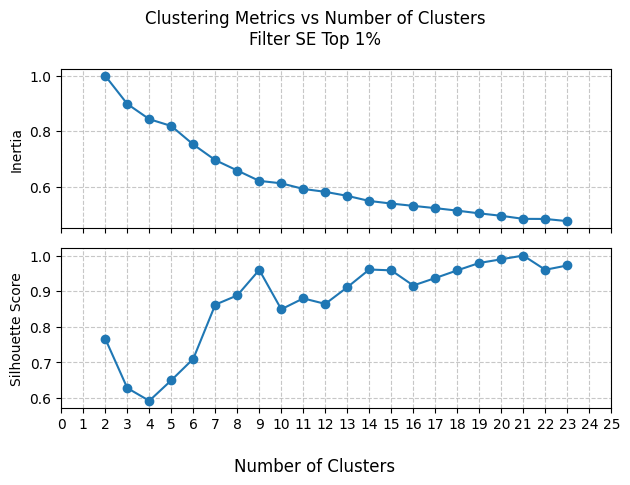

## Train and save

```python
start_time = time.perf_counter()
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(
    xai_dict["norm_unique_weights"]
)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save the model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/kmeans_model.joblib")
```
```
train time: 0.04 seconds
['/home/elom/phd/code/clustering/bin_03/mse_filter_250/kmeans_9_clusters_150_segments/kmeans_model.joblib']
```

## Save metadata

```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")

cluster_meta_df = meta_with_ratios_df.loc[specobjids_array].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
```

# Clusters metadata

In [ ]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_weights"],
    print_n_clusters=True,
)

xai_dict["spectra_cluster_dict"] = spectra_cluster_dict
xai_dict["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_unique_weights"],
    print_n_clusters=False,
)

xai_dict["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
xai_dict["centroids"] = centroids

# 0;227
# 1;98
# 2;474
# 3;184
# 4;73
# 5;178
# 6;223
# 7;69
# 8;293

0;227
1;98
2;474
3;184
4;73
5;178
6;223
7;69
8;293


In [14]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
)
cluster_meta_df.shape

(1819, 52)

# Avg Spec & Explanations

In [15]:
for label, centroid in enumerate(xai_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=None,
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

    axs[0].plot(wave_nm, avg_spectrum, color="black", label="Average spectrum")
    axs[0].legend()
    # weights
    axs[1].plot(wave_nm, centroid, color="black", label="Average explanation")
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Top ranked anomalies per cluster

In [24]:
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = xai_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
)

Number of anomalies in cluster 0: 227
Explanation for anomaly rank 1
Explanation for anomaly rank 2
Explanation for anomaly rank 3
Explanation for anomaly rank 4
Explanation for anomaly rank 5
Explanation for anomaly rank 6
Explanation for anomaly rank 7
Explanation for anomaly rank 8
Explanation for anomaly rank 9
Explanation for anomaly rank 10
Explanation for anomaly rank 11
Explanation for anomaly rank 12
Explanation for anomaly rank 13
Explanation for anomaly rank 14
Explanation for anomaly rank 15
Explanation for anomaly rank 16
Explanation for anomaly rank 17
Explanation for anomaly rank 18
Explanation for anomaly rank 19
Explanation for anomaly rank 20
Explanation for anomaly rank 21


# Line ratios

In [25]:
lines_cols = [
    "h_alpha_flux",
    "h_beta_flux",
    "nii_6548_flux",
    "nii_6584_flux",
    "sii_6717_flux",
    "sii_6731_flux",
    "oii_3726_flux",
    "oii_3729_flux",
    "oiii_4959_flux",
    "oiii_5007_flux",
    "oiii_flux",
]
cluster_meta_df[lines_cols].describe()

,h_alpha_flux,h_beta_flux,nii_6548_flux,nii_6584_flux,sii_6717_flux,sii_6731_flux,oii_3726_flux,oii_3729_flux,oiii_4959_flux,oiii_5007_flux,oiii_flux
count,1.779000e+03,1.772000e+03,1.754000e+03,1.754000e+03,1.707000e+03,1.711000e+03,1.339000e+03,1.358000e+03,1.704000e+03,1.768000e+03,1.771000e+03
mean,1.760467e+07,4.989428e+06,1.844849e+06,5.564490e+06,8.704647e+06,1.760793e+08,1.460533e+07,6.166428e+06,2.656667e+06,3.627812e+06,3.656661e+06
std,5.782993e+08,1.608409e+08,6.623184e+07,1.997705e+08,2.474328e+08,7.188085e+09,3.163725e+08,1.787694e+08,6.982418e+07,1.112902e+08,1.121025e+08
min,2.159138e-01,5.402843e-03,3.730642e-02,1.125248e-01,1.745283e-02,5.457369e-02,6.603864e-02,6.811889e-02,2.608672e-02,4.893990e-02,2.465294e-02
25%,2.565707e+02,7.075481e+01,2.392849e+01,7.217383e+01,6.290468e+01,4.323960e+01,4.549995e+01,4.529957e+01,1.996945e+01,4.591517e+01,4.682148e+01
50%,7.717072e+02,2.132489e+02,5.696440e+01,1.718177e+02,1.339990e+02,9.863401e+01,1.822480e+02,1.878684e+02,1.140318e+02,3.193071e+02,3.213557e+02
75%,1.582117e+03,4.364138e+02,1.221093e+02,3.683098e+02,2.274099e+02,1.685509e+02,4.580174e+02,4.507408e+02,3.514105e+02,1.001983e+03,1.014668e+03
max,2.292654e+10,6.261624e+09,2.727109e+09,8.225589e+09,9.422665e+09,2.973184e+11,9.037692e+09,6.529991e+09,2.468186e+09,4.029195e+09,4.046059e+09


In [26]:
n_nans = cluster_meta_df[lines_cols].isna().sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_nans,n_negatives,n_zeros
0,h_alpha_flux,40,0,0
1,h_beta_flux,47,0,0
2,nii_6548_flux,65,0,0
3,nii_6584_flux,65,0,0
4,sii_6717_flux,112,0,0
5,sii_6731_flux,108,0,0
6,oii_3726_flux,480,0,0
7,oii_3729_flux,461,0,0
8,oiii_4959_flux,115,0,0
9,oiii_5007_flux,51,0,0


In [27]:
# Compute deciles (10th to 90th percentiles) for each column
deciles = np.arange(0.01, 1.01, 0.01)
decile_df = cluster_meta_df[lines_cols].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df

,1th,2th,3th,4th,5th,6th,6th,8th,9th,10th,...,91th,92th,93th,94th,95th,96th,97th,98th,99th,100th
h_alpha_flux,3.513266,5.905969,8.140174,10.676639,14.350330,18.174829,23.545310,27.441655,33.785823,39.352814,...,2839.314100,3035.307840,3221.826500,3392.591600,3641.98440,4040.805680,4508.758820,5324.433800,6.309090e+03,2.292654e+10
h_beta_flux,0.810949,2.277306,2.931588,3.999180,6.198709,7.731425,9.116316,10.592370,12.600511,15.057317,...,797.259670,860.128136,897.307129,975.919526,1057.12730,1140.524000,1281.316570,1435.941460,1.676762e+03,6.261624e+09
nii_6548_flux,0.509845,1.078331,1.660767,2.582181,3.836492,4.975902,5.958830,6.959913,7.667360,8.545722,...,222.481139,233.578888,255.841200,272.842212,316.66416,360.337988,403.282958,476.433178,6.866601e+02,2.727109e+09
nii_6584_flux,1.537811,3.252495,5.009254,7.788452,11.571744,15.008473,17.973208,20.992710,23.126523,25.775869,...,671.054466,704.527836,771.676177,822.955156,955.13220,1086.863000,1216.394460,1437.032360,2.071125e+03,8.225589e+09
sii_6717_flux,1.564226,2.322364,3.582317,5.442791,7.816944,9.256939,11.225437,12.788270,15.287371,18.140124,...,350.370580,366.207776,379.624682,398.898492,424.62621,465.663696,524.391818,583.886260,7.030981e+02,9.422665e+09
sii_6731_flux,1.183201,2.396094,3.699149,4.580869,5.726767,7.285017,8.199962,9.377604,10.419004,12.035150,...,272.794950,282.806740,295.900460,309.239900,338.80735,368.997260,399.210580,477.018040,5.665525e+02,2.973184e+11
oii_3726_flux,0.959286,2.127023,3.224647,4.387434,5.337616,6.706018,8.977916,9.285191,10.440342,11.155694,...,883.280774,947.182344,1010.788120,1094.648320,1264.02750,1555.991520,2384.775980,46695.190400,1.633065e+06,9.037692e+09
oii_3729_flux,0.613714,1.379655,2.070460,3.626907,4.754077,7.057983,9.425058,10.918732,12.335353,13.748500,...,829.618696,864.888324,925.568291,982.673792,1117.22265,1210.349920,1391.196810,2146.965480,2.390021e+06,6.529991e+09
oiii_4959_flux,0.341027,0.720565,1.305199,1.671687,2.329868,2.824663,3.119683,3.636708,4.116400,4.923749,...,834.523519,895.923972,955.917959,1066.335820,1187.15340,1311.426360,1542.570150,1714.293980,2.109939e+03,2.468186e+09
oiii_5007_flux,1.515168,2.439940,3.411862,4.620056,5.626666,6.568327,7.656896,8.628446,9.856083,10.879268,...,2468.306850,2631.158320,2860.949370,3152.926520,3510.63035,3945.065440,4676.126410,5224.428180,6.253495e+03,4.029195e+09


In [28]:
# replace 0 with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].replace(0, np.nan)
# replace negative fluxes numeric values with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].where(
    cluster_meta_df[lines_cols] >= 0, np.nan
)
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
temp_df = pd.DataFrame({"n_negatives": n_negatives, "n_zeros": n_zeros})
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_negatives,n_zeros
0,h_alpha_flux,0,0
1,h_beta_flux,0,0
2,nii_6548_flux,0,0
3,nii_6584_flux,0,0
4,sii_6717_flux,0,0
5,sii_6731_flux,0,0
6,oii_3726_flux,0,0
7,oii_3729_flux,0,0
8,oiii_4959_flux,0,0
9,oiii_5007_flux,0,0


# Median line ratios

In [29]:
df, ratio_cols = astronomy.compute_emission_line_ratios(cluster_meta_df)
range_n_clusters = range(0, n_clusters)

median_cluster_ratios_df = pd.DataFrame(
    index=range_n_clusters,
    columns=ratio_cols,
)
for cluster_id in range_n_clusters:

    mask = df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        df.loc[mask, "sii_density_ratio"]
    )

median_cluster_ratios_df

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,3.378869,0.102942,3.54396,3.009966,1.480254,0.196589,1.357418
1,4.18913,0.59274,3.066601,3.78002,0.762153,0.31496,1.237886
2,3.650738,0.342221,0.756912,0.741409,0.257193,0.303999,1.398777
3,3.79341,0.252413,1.778542,1.672953,0.792282,0.221164,1.326029
4,3.966857,0.371917,1.780361,1.594874,0.763715,0.304874,1.27577
5,3.274621,0.125039,1.871617,1.012014,1.19553,0.267136,1.416227
6,3.934641,0.546725,0.970444,0.988882,0.171895,0.328052,1.331748
7,4.25834,0.638307,1.529954,2.701998,0.532145,0.328052,1.229947
8,3.365478,0.166388,1.642486,1.180941,0.986784,0.275322,1.400686


In [30]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = df[ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer_decrement,3.487975,3.506051,3.528186,3.551442,3.570776,3.595096,3.613802,3.625180,3.645039,3.666140,3.685424
nii_to_halpha,0.245660,0.249400,0.253896,0.261296,0.267933,0.275427,0.283360,0.289788,0.295509,0.303366,0.310543
oiii_to_hbeta,1.411438,1.452950,1.495171,1.536621,1.588201,1.634219,1.679685,1.709570,1.764755,1.794322,1.823865
oiii_to_oii,1.146317,1.171467,1.184126,1.224396,1.252324,1.279179,1.305374,1.347160,1.384855,1.412142,1.464562
o3n2_index,0.674363,0.685889,0.713143,0.734039,0.752545,0.766814,0.789062,0.802273,0.821757,0.849814,0.863104
sii_to_halpha,0.268890,0.270697,0.272935,0.275420,0.277378,0.279689,0.281651,0.284302,0.286828,0.288601,0.290834
sii_density_ratio,1.354354,1.357421,1.359972,1.362596,1.366476,1.369167,1.372304,1.374426,1.376302,1.380027,1.381937


## Cluster 0 ratios percentiles

In [31]:
cluster_mask = df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.291672,3.337209,3.378869,3.401947,3.452826
nii_to_halpha,0.085957,0.091560,0.102942,0.107675,0.120806
oiii_to_hbeta,3.189571,3.363808,3.543960,3.714155,3.951355
oiii_to_oii,2.615787,2.768227,3.009966,3.129102,3.438676
o3n2_index,1.360280,1.442696,1.480254,1.527946,1.577937
sii_to_halpha,0.180927,0.187028,0.196589,0.206228,0.219705
sii_density_ratio,1.335399,1.349632,1.357418,1.366974,1.376412


## Cluster 1 ratios percentiles

In [32]:
cluster_mask = df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,4.029989,4.168295,4.189130,4.242814,4.300678
nii_to_halpha,0.489053,0.542184,0.592740,0.613382,0.651685
oiii_to_hbeta,2.490814,2.818792,3.066601,3.707363,4.163626
oiii_to_oii,2.283631,3.251734,3.780020,4.298936,4.964027
o3n2_index,0.724077,0.744299,0.762153,0.802220,0.839448
sii_to_halpha,0.304933,0.308379,0.314960,0.339272,0.355627
sii_density_ratio,1.176500,1.212548,1.237886,1.256481,1.277822


## Cluster 2 percentiles

In [33]:
cluster_mask = df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.392341,3.509600,3.650738,3.756860,3.857941
nii_to_halpha,0.307042,0.324428,0.342221,0.358429,0.382603
oiii_to_hbeta,0.580493,0.672595,0.756912,0.862592,0.983118
oiii_to_oii,0.629562,0.674698,0.741409,0.843630,0.935303
o3n2_index,0.122058,0.181529,0.257193,0.370652,0.455396
sii_to_halpha,0.287880,0.294816,0.303999,0.313561,0.327014
sii_density_ratio,1.366283,1.382082,1.398777,1.410801,1.428853


## Cluster 3 ratios percentiles

In [34]:
cluster_mask = df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.650822,3.713636,3.793410,3.872248,3.951538
nii_to_halpha,0.208014,0.222090,0.252413,0.289721,0.323608
oiii_to_hbeta,1.363432,1.534304,1.778542,1.876822,1.969874
oiii_to_oii,1.470372,1.560952,1.672953,1.759297,1.964118
o3n2_index,0.576347,0.688266,0.792282,0.874153,0.973570
sii_to_halpha,0.208028,0.216199,0.221164,0.232034,0.241617
sii_density_ratio,1.287259,1.306912,1.326029,1.336703,1.358779


## Cluster 4 ratios percentiles

In [35]:
cluster_mask = df["cluster"] == 4
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.861069,3.909797,3.966857,4.050937,4.075904
nii_to_halpha,0.322147,0.349019,0.371917,0.415270,0.481993
oiii_to_hbeta,1.401215,1.595691,1.780361,2.209362,2.623247
oiii_to_oii,1.357335,1.477558,1.594874,2.278896,3.473916
o3n2_index,0.690076,0.732075,0.763715,0.778420,0.797886
sii_to_halpha,0.286720,0.290021,0.304874,0.318540,0.330804
sii_density_ratio,1.262070,1.266694,1.275770,1.285026,1.303118


## Cluster 5 percentiles

In [36]:
cluster_mask = df["cluster"] == 5
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.193729,3.210667,3.274621,3.351082,3.389500
nii_to_halpha,0.105781,0.113222,0.125039,0.142071,0.161692
oiii_to_hbeta,1.408777,1.703805,1.871617,2.046682,2.193858
oiii_to_oii,0.888340,0.978765,1.012014,1.310753,1.548666
o3n2_index,0.962000,1.114353,1.195530,1.274367,1.324855
sii_to_halpha,0.239989,0.254331,0.267136,0.274942,0.286288
sii_density_ratio,1.401357,1.409457,1.416227,1.419835,1.423411


## Cluster 6 percentiles

In [37]:
cluster_mask = df["cluster"] == 6
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.638885,3.842379,3.934641,4.017156,4.107742
nii_to_halpha,0.443069,0.490353,0.546725,0.584228,0.672745
oiii_to_hbeta,0.745003,0.868692,0.970444,1.106108,1.336455
oiii_to_oii,0.807530,0.881356,0.988882,1.098703,1.234891
o3n2_index,0.082372,0.113194,0.171895,0.246648,0.307976
sii_to_halpha,0.302777,0.314890,0.328052,0.375304,0.419351
sii_density_ratio,1.261412,1.284011,1.331748,1.351252,1.387404


## Cluster 7 percentiles

In [38]:
cluster_mask = df["cluster"] == 7
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,4.092800,4.215848,4.258340,4.321474,4.443141
nii_to_halpha,0.515266,0.601132,0.638307,0.669165,0.689108
oiii_to_hbeta,1.246828,1.394997,1.529954,2.159015,3.452562
oiii_to_oii,1.895730,2.366296,2.701998,3.445375,3.671459
o3n2_index,0.306216,0.484412,0.532145,0.574703,0.682031
sii_to_halpha,0.285233,0.302112,0.328052,0.353207,0.386329
sii_density_ratio,1.173970,1.185583,1.229947,1.246233,1.260656


## Cluster 8 percentiles

In [39]:
cluster_mask = df["cluster"] == 8
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.248429,3.313909,3.365478,3.400975,3.446046
nii_to_halpha,0.147863,0.158184,0.166388,0.179805,0.190329
oiii_to_hbeta,1.409449,1.515483,1.642486,1.695188,1.817824
oiii_to_oii,1.024507,1.114551,1.180941,1.277792,1.375633
o3n2_index,0.865538,0.925187,0.986784,1.023772,1.085915
sii_to_halpha,0.256975,0.267879,0.275322,0.284445,0.292618
sii_density_ratio,1.376304,1.388949,1.400686,1.409885,1.420093


# Redshift Analysis

In [40]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010132,0.242462,0.047051,0.029918
1,1,0.041688,0.243756,0.116222,0.118355
2,2,0.012135,0.294866,0.090139,0.073202
3,3,0.010354,0.282081,0.073899,0.057209
4,4,0.074165,0.111203,0.107962,0.108252
5,5,0.010093,0.151883,0.023868,0.014529
6,6,0.016985,0.229779,0.098800,0.089127
7,7,0.011381,0.263567,0.114729,0.111929
8,8,0.017390,0.237981,0.052092,0.032031


In [41]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010132,0.242462,0.047051,0.029918,5509.182778,5533.932027,4479.010223,4499.131563,5314.929766,5338.806360,5403.344994,5427.618781
1,1,0.041688,0.243756,0.116222,0.118355,5342.293000,5366.292520,4474.352073,4494.452487,4985.569325,5007.966312,4976.057251,4998.411507
2,2,0.012135,0.294866,0.090139,0.073202,5498.276871,5522.977126,4297.740346,4317.047356,5104.852347,5127.785197,5185.417146,5208.711922
3,3,0.010354,0.282081,0.073899,0.057209,5507.972000,5532.715810,4340.597692,4360.097233,5182.052036,5205.331695,5263.861535,5287.508712
4,4,0.074165,0.111203,0.107962,0.108252,5180.766919,5204.040805,5008.083578,5030.581707,5022.737474,5045.301434,5021.421121,5043.979167
5,5,0.010093,0.151883,0.023868,0.014529,5509.396417,5534.146625,4831.220676,4852.924273,5435.268751,5459.685951,5485.303937,5509.945913
6,6,0.016985,0.229779,0.098800,0.089127,5472.056949,5496.639415,4525.203309,4545.532165,5064.618073,5087.370176,5109.596906,5132.551070
7,7,0.011381,0.263567,0.114729,0.111929,5502.379673,5527.098360,4404.197893,4423.983149,4992.242768,5014.669734,5004.815505,5027.298953
8,8,0.017390,0.237981,0.052092,0.032031,5469.877087,5494.449760,4495.221374,4515.415540,5289.459225,5313.221396,5392.277793,5416.501862
